In [9]:
# Manejo y análisis de datos tabulares
import pandas as pd

# Computación vectorial y científica
import numpy as np

# Graficación y visualización
from matplotlib import pyplot

In [10]:
# CARGA DEL DATASET

# Cargar el dataset
df = pd.read_csv('OnlineNewsPopularity.csv')

# Dimensiones generales
print(f"Filas:    {df.shape[0]}")
print(f"Columnas: {df.shape[0]}")

# Primeras 5 filas
print("\nPrimeras 5 filas:")
print(df.head())

Filas:    39644
Columnas: 39644

Primeras 5 filas:
                                                 url   timedelta  \
0  http://mashable.com/2013/01/07/amazon-instant-...       731.0   
1  http://mashable.com/2013/01/07/ap-samsung-spon...       731.0   
2  http://mashable.com/2013/01/07/apple-40-billio...       731.0   
3  http://mashable.com/2013/01/07/astronaut-notre...       731.0   
4   http://mashable.com/2013/01/07/att-u-verse-apps/       731.0   

    n_tokens_title   n_tokens_content   n_unique_tokens   n_non_stop_words  \
0             12.0              219.0          0.663594                1.0   
1              9.0              255.0          0.604743                1.0   
2              9.0              211.0          0.575130                1.0   
3              9.0              531.0          0.503788                1.0   
4             13.0             1072.0          0.415646                1.0   

    n_non_stop_unique_tokens   num_hrefs   num_self_hrefs   num_imgs  .

In [13]:
# PREPROCESAMIENTO DE DATOS6


# Eliminar columnas no predictivas
# - url: texto, no numérica
# - timedelta: marcada como non-predictive en el dataset
df = df.drop(columns=['url', ' timedelta'])

# Separar X e y
y = df[' shares'].values
X = df.drop(columns=[' shares']).values

# m = ejemplos de entrenamiento, n = features
m, n = X.shape
print(f"Ejemplos (m): {m}")
print(f"Features  (n): {n}")
print(f"Dimensiones de X: {X.shape}")
print(f"Dimensiones de y: {y.shape}")

Ejemplos (m): 39644
Features  (n): 58
Dimensiones de X: (39644, 58)
Dimensiones de y: (39644,)


In [14]:
#DIVISIÓN TRAIN Y TEST

# 80% entrenamiento, 20% prueba
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(f"Ejemplos de entrenamiento: {X_train.shape[0]}")
print(f"Ejemplos de prueba:        {X_test.shape[0]}")


Ejemplos de entrenamiento: 31715
Ejemplos de prueba:        7929


In [15]:
# NORMALIZACIÓN

def featureNormalize(X):
    X_norm = X.copy()
    mu = np.zeros(X.shape[1])
    sigma = np.zeros(X.shape[1])

    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma


# mu y sigma se calculan del train para no filtrar info del test
X_train_norm, mu, sigma = featureNormalize(X_train)

# Aplicar la misma normalización al test
X_test_norm = (X_test - mu) / sigma

print(f"Media (mu) primeros 5 valores:            {mu[:5]}")
print(f"Desviación estándar (sigma) primeros 5:   {sigma[:5]}")
print(f"X_train normalizado primeras 5 filas:")
print(X_train_norm[:5])

Media (mu) primeros 5 valores:            [ 10.40268012 550.33602396   0.55197376   1.00283777   0.69298368]
Desviación estándar (sigma) primeros 5:   [  2.12134169 473.58556782   3.93563271   5.84801931   3.64932894]
X_train normalizado primeras 5 filas:
[[ 2.16717557e+00  1.63991433e-01 -1.07390681e-02 -4.85253448e-04
  -1.31256308e-02  2.74250913e-01 -6.00388127e-01 -4.27950683e-01
  -3.01913649e-01  6.42748923e-01 -1.19236757e-01 -2.36950893e-01
  -4.67485062e-01  2.31176747e+00 -2.50385041e-01 -4.77719844e-01
  -5.18364250e-01 -3.87427026e-01 -1.20475126e-01 -2.33194712e-02
  -1.03570869e-01  4.21847211e-01  5.55255142e-01  3.60465057e-01
   1.02275620e-01  4.92993755e-01 -1.73842154e-01 -2.30251801e-01
  -2.40441925e-01 -4.52339541e-01  2.09262289e+00 -4.78814751e-01
  -4.72485111e-01 -4.10887790e-01 -2.57699199e-01 -2.71212634e-01
  -3.87904324e-01  1.09373590e+00 -5.14313103e-01 -6.62564424e-01
   7.44176816e-01 -7.10301257e-01 -1.09240311e+00 -7.40172930e-01
  -8.13182690e-01 

# Regresión lineal multivariable

In [16]:

# BLOQUE 6: AGREGAR BIAS

# Agregar columna de unos al inicio de X_train y X_test
X_train_b = np.concatenate([np.ones((X_train_norm.shape[0], 1)), X_train_norm], axis=1)
X_test_b = np.concatenate([np.ones((X_test_norm.shape[0], 1)), X_test_norm], axis=1)

print(f"Dimensiones X_train con bias: {X_train_b.shape}")
print(f"Dimensiones X_test con bias:  {X_test_b.shape}")

Dimensiones X_train con bias: (31715, 59)
Dimensiones X_test con bias:  (7929, 59)


In [17]:
# FUNCIONES DE COSTO Y GRADIENTE

def computeCostMulti(X, y, theta):
    m = y.shape[0]
    J = (1 / (2 * m)) * np.sum(np.square(np.dot(X, theta) - y))
    return J

def gradientDescentMulti(X, y, theta, alpha, num_iters):
    m = y.shape[0]
    theta = theta.copy()
    J_history = []

    for i in range(num_iters):
        theta = theta - (alpha / m) * (np.dot(X, theta) - y).dot(X)
        J_history.append(computeCostMulti(X, y, theta))

    return theta, J_history

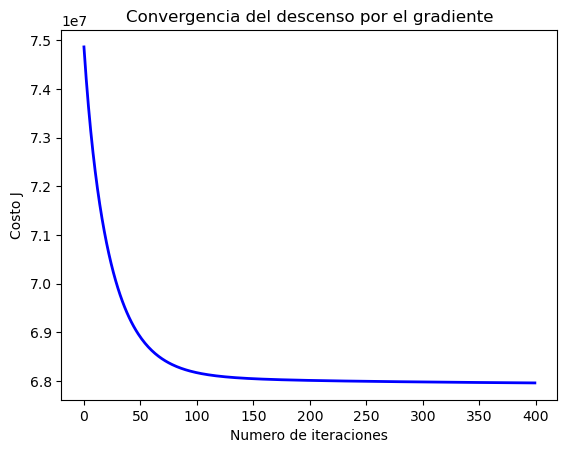

Costo final en train: 67961246.70
Costo final en test:  58835747.55
Primeros 5 valores de theta: [3.41131397e+03 2.38461051e+02 1.96246395e+02 1.44687002e+01
 2.43897403e+00]


In [19]:
# ENTRENAMIENTO
# Parámetros del modelo
alpha = 0.02
num_iters = 400

# Inicializa theta con ceros (1 bias + 58 features)
theta = np.zeros(59)

# Ejecuta el descenso por el gradiente con datos de entrenamiento
theta, J_history = gradientDescentMulti(X_train_b, y_train, theta, alpha, num_iters)

# Grafica la convergencia del costo
pyplot.plot(np.arange(len(J_history)), J_history, lw=2, color='blue')
pyplot.xlabel('Numero de iteraciones')
pyplot.ylabel('Costo J')
pyplot.title('Convergencia del descenso por el gradiente')
pyplot.show()

# Costo final en train y test
costo_train = computeCostMulti(X_train_b, y_train, theta)
costo_test = computeCostMulti(X_test_b, y_test, theta)

print(f"Costo final en train: {costo_train:.2f}")
print(f"Costo final en test:  {costo_test:.2f}")
print(f"Primeros 5 valores de theta: {theta[:5]}")

In [20]:
# PREDICCIONES

# Tomar 100 ejemplos del set de test
X_pred = X_test_b[:100]
y_real = y_test[:100]

# Realizar predicciones
y_pred = np.dot(X_pred, theta)

# Evitar predicciones negativas
y_pred = np.maximum(0, y_pred)

# Mostrar comparación de predicciones vs valores reales
print(f"{'#':>4} {'Shares Reales':>15} {'Shares Predichos':>17} {'Error':>10}")
print("-" * 50)
for i in range(100):
    error = y_real[i] - y_pred[i]
    print(f"{i+1:>4} {y_real[i]:>15.0f} {y_pred[i]:>17.0f} {error:>10.0f}")

# Métricas generales de las 100 predicciones
mae = np.mean(np.abs(y_real - y_pred))
print(f"\nError promedio (MAE): {mae:.2f} shares")
print(f"Shares reales promedio:   {np.mean(y_real):.2f}")
print(f"Shares predichos promedio:{np.mean(y_pred):.2f}")

   #   Shares Reales  Shares Predichos      Error
--------------------------------------------------
   1            2900              2879         21
   2            1300              2476      -1176
   3           17700              5691      12009
   4            1500              2486       -986
   5            1400              2031       -631
   6            2900              2675        225
   7             801              2861      -2060
   8            3000              3664       -664
   9            1000              1833       -833
  10             367              2486      -2119
  11            4700              3425       1275
  12            1700              6414      -4714
  13           17800              4986      12814
  14           17800              7830       9970
  15             884              1520       -636
  16            1500              3003      -1503
  17            7400              5597       1803
  18            1200              2204      -1004

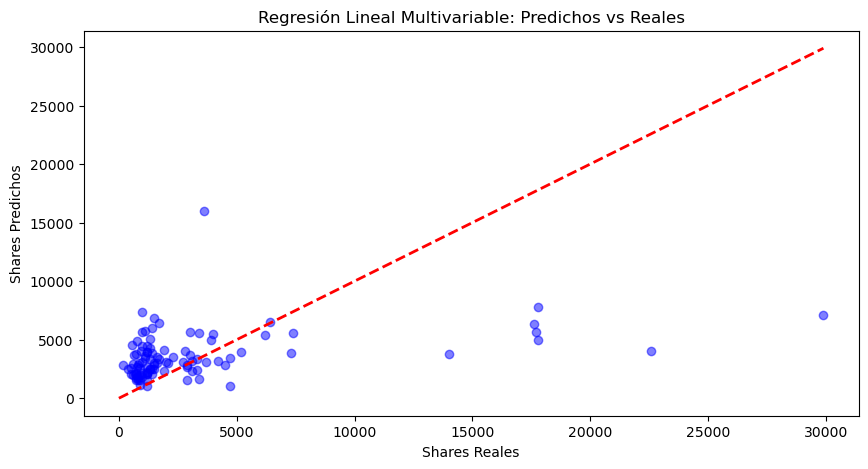

In [26]:
# Gráfica predichos vs reales - Regresión Lineal Multivariable
pyplot.figure(figsize=(10, 5))
pyplot.scatter(y_real, y_pred, alpha=0.5, color='blue')
pyplot.plot([0, max(y_real)], [0, max(y_real)], 'r--', lw=2)
pyplot.xlabel('Shares Reales')
pyplot.ylabel('Shares Predichos')
pyplot.title('Regresión Lineal Multivariable: Predichos vs Reales')
pyplot.show()

# Ecuación de la normal

In [ ]:
#Definimos la función de la ecuación normal

def normalEqn(X, y):
    # θ = (XᵀX)⁻¹ Xᵀy
    theta = np.dot(np.dot(np.linalg.inv(np.dot(X.T, X)), X.T), y)
    return theta

# Calcular theta directamente sin iteraciones
# Usamos X_train_b que ya tiene el bias agregado
theta_normal = normalEqn(X_train_b, y_train)

# Costo en train y test
costo_train_normal = computeCostMulti(X_train_b, y_train, theta_normal)
costo_test_normal = computeCostMulti(X_test_b, y_test, theta_normal)

print(f"Theta calculado por ecuación normal (primeros 5): {theta_normal[:5]}")
print(f"\nCosto final en train: {costo_train_normal:.2f}")
print(f"Costo final en test:  {costo_test_normal:.2f}")

Theta calculado por ecuación normal (primeros 5): [  3412.36954123    255.75288831    393.68887797  14160.03573973
 -14335.70221764]

Costo final en train: 68029719.45
Costo final en test:  58908175.26


In [23]:
# PREDICCIONES ECUACIÓN NORMAL

# Tomar 100 ejemplos del set de test
X_pred = X_test_b[:100]
y_real = y_test[:100]

# Realizar predicciones
y_pred_normal = np.dot(X_pred, theta_normal)

# Evitar predicciones negativas
y_pred_normal = np.maximum(0, y_pred_normal)

# Mostrar comparación
print(f"{'#':>4} {'Shares Reales':>15} {'Shares Predichos':>17} {'Error':>10}")
print("-" * 50)
for i in range(100):
    error = y_real[i] - y_pred_normal[i]
    print(f"{i+1:>4} {y_real[i]:>15.0f} {y_pred_normal[i]:>17.0f} {error:>10.0f}")

# Métricas generales
mae_normal = np.mean(np.abs(y_real - y_pred_normal))
print(f"\nError promedio (MAE): {mae_normal:.2f} shares")
print(f"Shares reales promedio:    {np.mean(y_real):.2f}")
print(f"Shares predichos promedio: {np.mean(y_pred_normal):.2f}")

   #   Shares Reales  Shares Predichos      Error
--------------------------------------------------
   1            2900              2609        291
   2            1300              2574      -1274
   3           17700              6488      11212
   4            1500              3398      -1898
   5            1400              1543       -143
   6            2900              2497        403
   7             801              3122      -2321
   8            3000              3066        -66
   9            1000              1430       -430
  10             367              3666      -3299
  11            4700              2925       1775
  12            1700              5990      -4290
  13           17800              3027      14773
  14           17800              8730       9070
  15             884              2765      -1881
  16            1500              2440       -940
  17            7400              5573       1827
  18            1200              1646       -446

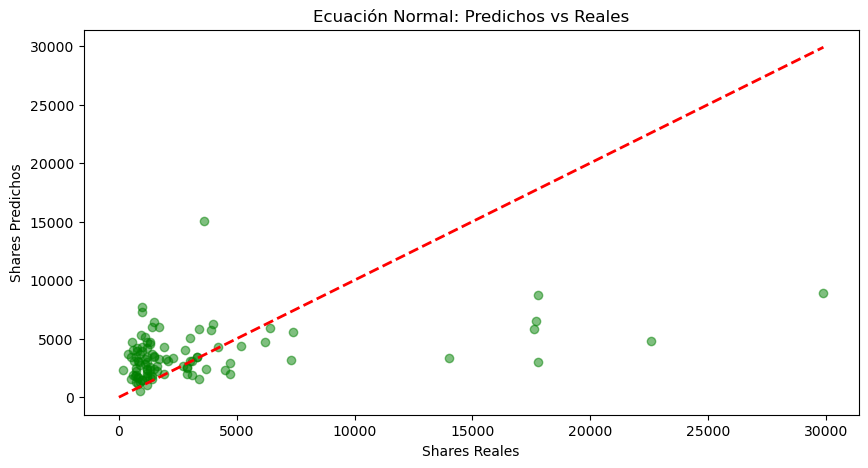

In [24]:
pyplot.figure(figsize=(10, 5))
pyplot.scatter(y_real, y_pred_normal, alpha=0.5, color='green')
pyplot.plot([0, max(y_real)], [0, max(y_real)], 'r--', lw=2)
pyplot.xlabel('Shares Reales')
pyplot.ylabel('Shares Predichos')
pyplot.title('Ecuación Normal: Predichos vs Reales')
pyplot.show()

# Regresión Polinómica

In [28]:
# Agregar features al cuadrado (grado 2)
X_train_poly = np.concatenate([X_train, X_train**2], axis=1)
X_test_poly = np.concatenate([X_test, X_test**2], axis=1)

# Normalizar
X_train_poly_norm, mu_poly, sigma_poly = featureNormalize(X_train_poly)
X_test_poly_norm = (X_test_poly - mu_poly) / sigma_poly

# Agregar bias
X_train_poly_b = np.concatenate([np.ones((X_train_poly_norm.shape[0], 1)), X_train_poly_norm], axis=1)
X_test_poly_b = np.concatenate([np.ones((X_test_poly_norm.shape[0], 1)), X_test_poly_norm], axis=1)

print(f"Features originales:   {X_train.shape[1]}")
print(f"Features polinómicas:  {X_train_poly_b.shape[1]}")

# Entrenar
alpha = 0.01
num_iters = 400
theta_poly = np.zeros(X_train_poly_b.shape[1])
theta_poly, J_history_poly = gradientDescentMulti(X_train_poly_b, y_train, theta_poly, alpha, num_iters)

costo_train_poly = computeCostMulti(X_train_poly_b, y_train, theta_poly)
costo_test_poly = computeCostMulti(X_test_poly_b, y_test, theta_poly)
print(f"Costo final en train: {costo_train_poly:.2f}")
print(f"Costo final en test:  {costo_test_poly:.2f}")

Features originales:   58
Features polinómicas:  117
Costo final en train: 67776399.17
Costo final en test:  58411571.68


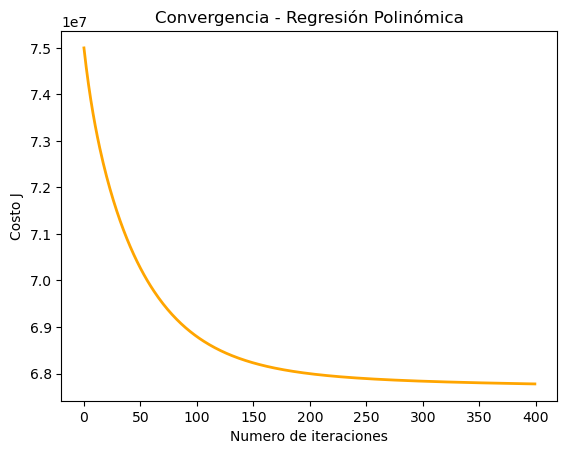

In [29]:
pyplot.plot(np.arange(len(J_history_poly)), J_history_poly, lw=2, color='orange')
pyplot.xlabel('Numero de iteraciones')
pyplot.ylabel('Costo J')
pyplot.title('Convergencia - Regresión Polinómica')
pyplot.show()

   #   Shares Reales  Shares Predichos      Error
--------------------------------------------------
   1            2900              2780        120
   2            1300              2320      -1020
   3           17700              5903      11797
   4            1500              2223       -723
   5            1400              2050       -650
   6            2900              2649        251
   7             801              2725      -1924
   8            3000              3827       -827
   9            1000              1696       -696
  10             367              2325      -1958
  11            4700              3429       1271
  12            1700              5141      -3441
  13           17800              5858      11942
  14           17800              7430      10370
  15             884              1463       -579
  16            1500              2774      -1274
  17            7400              5430       1970
  18            1200              2081       -881

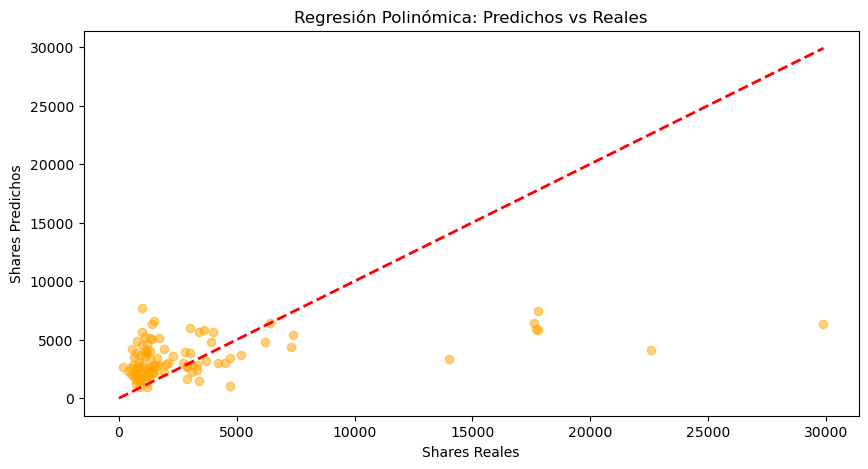

In [30]:
# 100 predicciones
X_pred_poly = X_test_poly_b[:100]
y_pred_poly = np.dot(X_pred_poly, theta_poly)
y_pred_poly = np.maximum(0, y_pred_poly)

# Tabla
print(f"{'#':>4} {'Shares Reales':>15} {'Shares Predichos':>17} {'Error':>10}")
print("-" * 50)
for i in range(100):
    error = y_real[i] - y_pred_poly[i]
    print(f"{i+1:>4} {y_real[i]:>15.0f} {y_pred_poly[i]:>17.0f} {error:>10.0f}")

mae_poly = np.mean(np.abs(y_real - y_pred_poly))
print(f"\nError promedio (MAE): {mae_poly:.2f} shares")

# Gráfica predichos vs reales
pyplot.figure(figsize=(10, 5))
pyplot.scatter(y_real, y_pred_poly, alpha=0.5, color='orange')
pyplot.plot([0, max(y_real)], [0, max(y_real)], 'r--', lw=2)
pyplot.xlabel('Shares Reales')
pyplot.ylabel('Shares Predichos')
pyplot.title('Regresión Polinómica: Predichos vs Reales')
pyplot.show()